In [69]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [70]:
train_path = r"E:\GEN AI PROJECT\fake image detector\real vs fake images\train"
test_path = r"E:\GEN AI PROJECT\fake image detector\real vs fake images\test"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# random.shuffle(image_files)
# # ['fake', 'real']

Found 1289 files belonging to 2 classes.
Found 685 files belonging to 2 classes.


In [78]:
class_name = train_ds.class_names
num_classes = len(class_name)
print(class_name, num_classes)

['fake', 'real'] 2


In [79]:
def noramalize_img(image, label):
    image = tf.cast(image/255.0, tf.float32)
    return image, label

train_ds = train_ds.map(noramalize_img)
test_ds = test_ds.map(noramalize_img)

In [80]:
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(256, 256, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))

model.add(Conv2D(32, (3, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))

model.add(Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))

model.add(Conv2D(64, (3, 3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))

model.add(Flatten())

model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=num_classes, activation='softmax'))

In [81]:
model.compile(optimizer='adam',loss= "categorical_crossentropy",metrics=['accuracy'])

In [82]:
history = model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8883 - loss: 0.2511 - val_accuracy: 0.9971 - val_loss: 0.0101
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9907 - loss: 0.0312 - val_accuracy: 0.9971 - val_loss: 0.0047
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9969 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 3.3934e-04
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 1.0000 - loss: 2.4525e-04 - val_accuracy: 1.0000 - val_loss: 1.3643e-04
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 1.0000 - loss: 3.4087e-04 - val_accuracy: 1.0000 - val_loss: 1.4390e-04
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 1.0000 - loss: 2.7921e-04 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 1.0000 - loss: 3.7511e-04 - val_accuracy: 1.0000 - val_loss: 1.2216e-04
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 1.0000 - loss: 4.4232e-0

In [83]:
model.save("fake_image_detector_model.h5")

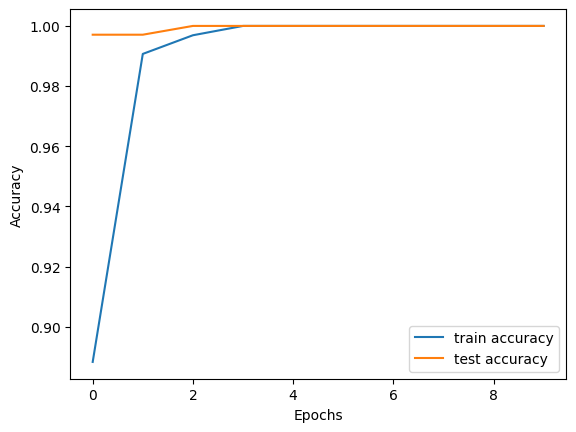

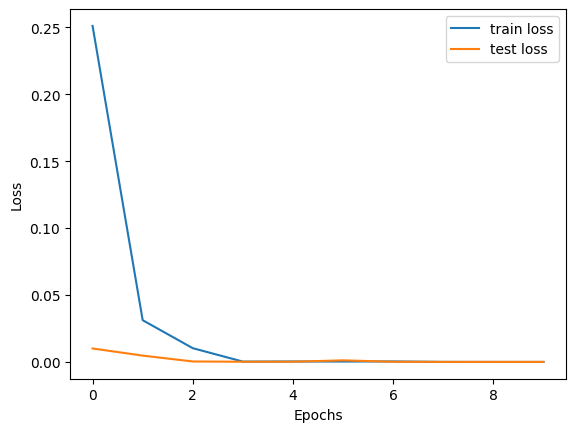

In [84]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [1]:
from tensorflow.keras.models import load_model
model = load_model("fake_image_detector_model.h5")


In [2]:
image_path = r"E:\GEN AI PROJECT\fake image detector\real vs fake images\test\real\real_589.jpg"

In [92]:
import cv2

# Function to preprocess an image
def preprocess_image(image_path):
    img = cv2.imread(image_path)  # Load the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (256, 256))  # Resize to 224x224
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

In [93]:
# Preprocess and predict
processed_image = preprocess_image(image_path)
prediction = model.predict(processed_image)

# Get class label
# Instead of train_data.class_indices, use class_names obtained earlier
class_labels = class_name  # Get class names from training data
predicted_class = class_labels[np.argmax(prediction)]  # Get predicted class

print(f"Predicted Disease: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Disease: real
